In [1]:
# TODO:
# TODO:
# TODO:

In [2]:
import time
import json
import math

# ! will NEED PyTorch version 2.5+ --> for scaled_dot_product_attention(enable_gqa=True)
import torch
import torch.nn as nn
from einops import rearrange
from kv_cache import KV_cache
import torch.nn.functional as F
from typing import Optional, Tuple
import training_engine as training_engine 
from tensor_tools import init_custom_weight
from model_config import ModelConfig, AttentionConfig, FFNConfig
from rotary_pos_enc import RotaryEmbedding, apply_rotary_pos_emb
from inference_engine import advanced_inference, load_model_weights


device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:   {torch.version.cuda}")

    print(f"device capability: {torch.cuda.get_device_capability()}")
    print(f"flash_attention_available: {torch.backends.cuda.is_flash_attention_available()}")




Device:         cuda
PyTorch:        2.8.0+cu129
GPU:            NVIDIA GeForce GTX 1660 Ti
CUDA version:   12.9
device capability: (7, 5)
flash_attention_available: False


In [3]:

configs = ModelConfig(

    model_name="level3_FFN_models",
    tied_embeddings=False,  
    
    embed_dim=2**5,   # 32
    vocab_size=2**11,  # 2048
    num_layers=5,
    max_training_batch_size=2**4,   # 16
    max_context_window=2**6,   # 64    
    learning_rate=1e-3,

    attention=AttentionConfig(
        num_q_heads =2**0,  # 1 | 1   x   x    x
        num_kv_heads=2**0,  # 1 | 1   1   2+   x
        rope_theta  =10000.0, 
    ),
    
    ffn=FFNConfig(
        mlp_to_embed_expand_factor= 2**2,
        use_gate=True,
        hidden_multiple_of=8,
        MoE_num_experts= 2**3, # dense if 1, MoE if more
        MoE_num_experts_per_tkn=2**2,
        MoE_capacity_factor=1.25,
        MoE_router_aux_loss_coef=0.01,
        MoE_router_z_loss_coef=0.0
    ),

    save_path       = "../models/level3_FFN_models.pt",
    val_loss_history= "../models/level3_FFN_models_val_loss_history.txt",

    checkpoint_dir= "../checkpoints/",
    checkpoint_every_steps= 250,
    keep_last_n_checkpoints= 3,

)

print(configs)
print(configs.head_dim)
print(configs.ffn_hidden_dim)

ModelConfig(model_name='level3_FFN_models', tied_embeddings=False, max_training_batch_size=16, embed_dim=32, vocab_size=2048, max_context_window=64, num_layers=5, learning_rate=0.001, attention=AttentionConfig(num_q_heads=1, num_kv_heads=1, rope_theta=10000.0), ffn=FFNConfig(use_gate=True, mlp_to_embed_expand_factor=4, hidden_multiple_of=8, MoE_num_experts=8, MoE_num_experts_per_tkn=4, MoE_capacity_factor=1.25, MoE_router_aux_loss_coef=0.01, MoE_router_z_loss_coef=0.0), save_path='../models/level3_FFN_models.pt', val_loss_history='../models/level3_FFN_models_val_loss_history.txt', checkpoint_dir='../checkpoints/', checkpoint_every_steps=250, keep_last_n_checkpoints=3)
32
128


In [4]:
# Attention

class Attention_SubBlock(nn.Module):

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.embed_dim    = cfg.embed_dim
        self.num_q_heads  = cfg.attention.num_q_heads
        self.num_kv_heads = cfg.attention.num_kv_heads
        self.num_layers   = cfg.num_layers
        
        if self.embed_dim % self.num_q_heads != 0:
            raise ValueError("embed_dim must be divisible by num_q_heads")
        if self.num_q_heads % self.num_kv_heads != 0:
            raise ValueError("num_q_heads must be divisible by num_kv_heads")

        self.head_dim = self.embed_dim // self.num_q_heads
        self.q_dim    = self.num_q_heads * self.head_dim
        self.kv_dim   = self.num_kv_heads * self.head_dim

        # ONE matrix for Q, K and V: columns are [ q | k | v ]
        self.W_qkv = nn.Parameter(torch.empty(self.embed_dim, self.q_dim + 2 * self.kv_dim))
        self.W_o   = nn.Parameter(torch.empty(self.q_dim, self.embed_dim))

        self.init_params()



    def init_params(self):

        q_end = self.q_dim
        k_end = q_end + self.kv_dim

        W_q = self.W_qkv[:, :q_end]
        W_k = self.W_qkv[:, q_end:k_end]
        W_v = self.W_qkv[:, k_end:]

        init_custom_weight(W_q, is_residual_output=False)
        init_custom_weight(W_k, is_residual_output=False)
        init_custom_weight(W_v, is_residual_output=False)

        # Residual output projection (scaled by depth)
        init_custom_weight(self.W_o, 
                           is_residual_output=True, 
                           num_layers=self.num_layers)


    def forward(
        self,
        x:   torch.Tensor,
        cos: torch.Tensor,          # [B, 1, seq, head_dim] – already computed
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
        
        lane_ids:  Optional[torch.Tensor] = None,
        attn_mask: Optional[torch.Tensor] = None,   # [B, 1, T, kv_len] bool, from cache.prepare()
   
    ) -> torch.Tensor:

        batch_size, seq_len, embed_dim = x.shape

        qkv = x @ self.W_qkv  # [B, T, q_dim + 2*kv_dim]
        q, k, v = qkv.split([self.q_dim, self.kv_dim, self.kv_dim], dim=-1)


        q = rearrange(q, 
                      "batch_size seq_len (num_q_heads head_dim)" 
                      " -> " 
                      "batch_size num_q_heads seq_len head_dim", 
                      num_q_heads=self.num_q_heads)
        
        k = rearrange(k, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)
        
        v = rearrange(v, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)


        q, k = apply_rotary_pos_emb(q, k, cos, sin)


        if cache is not None:
            k, v = cache.update(layer_idx, lane_ids, k, v)



        # The mask rule is that a query at absolute position p may attend to a key at 
        # absolute position a iff p - W < a <= p. The <= p part is causality, 
        # and the > p - W part is the sliding window. 
        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            is_causal=(attn_mask is None), # fast path only when no mask is given
            enable_gqa=(self.num_q_heads != self.num_kv_heads),
        )


        # Merge attention heads
        out = rearrange(
            out,
            "batch_size num_q_heads seq_len head_dim"
            " -> " 
            "batch_size seq_len (num_q_heads head_dim)",
        )


        return out @ self.W_o


* every FFN sub-block maps [B, T, D] -> ([B, T, D], aux_loss)

* aux_loss is a float32 scalar tensor. It is 0 for the dense blocks\
     and the (already coefficient-scaled) router loss for the MoE

In [5]:
# FFN helper functions 


def _zero_aux(x: torch.Tensor) -> torch.Tensor:
    return x.new_zeros((), dtype=torch.float32)


def _ffn_activation(h: torch.Tensor, gated: bool) -> torch.Tensor:
    """h: [..., 2*H] ([gate | up]) if gated else [..., H]  ->  [..., H]"""
    if gated:
        gate, up = h.chunk(2, dim=-1)
        return F.silu(gate) * up
    return F.silu(h)


In [6]:
class MLP_SubBlock(nn.Module):
    """Position-wise FFN: D -> H -> D with SiLU. Each token is processed independently."""

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.num_layers = cfg.num_layers

        self.W_up   = nn.Parameter(torch.empty(
            cfg.embed_dim, cfg.ffn_hidden_dim
            )
        )
        
        self.W_down = nn.Parameter(torch.empty(
            cfg.ffn_hidden_dim, cfg.embed_dim
            )
        )

        self._init_weights()


    def _init_weights(self):
        init_custom_weight(self.W_up,   is_residual_output=False)
        
        init_custom_weight(self.W_down, is_residual_output=True , 
                                        num_layers=self.num_layers)

  
    def forward(self, x:torch.Tensor)-> Tuple[torch.Tensor, torch.Tensor]:
        out = _ffn_activation(x @ self.W_up, gated=False) @ self.W_down
        return out, _zero_aux(x)
        


In [7]:
class GLU_SubBlock(nn.Module):
    """Gated FFN (SwiGLU). Params: W_gate_up [D, 2H] (= [gate | up]) and W_down [H, D]."""

    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.num_layers = cfg.num_layers
        self.hidden_dim = cfg.ffn_hidden_dim

        self.W_gate_up  = nn.Parameter(torch.empty(
            cfg.embed_dim, 2 * self.hidden_dim
            )
        )

        
        self.W_down = nn.Parameter(torch.empty(
            self.hidden_dim, cfg.embed_dim
            )
        )


        self._init_weights()


    def _init_weights(self):
        H = self.hidden_dim

        # initialise the two halves separately so each sees a [D, H] matrix
        init_custom_weight(self.W_gate_up[:, :H],   is_residual_output=False) # gate
        init_custom_weight(self.W_gate_up[:, H:],   is_residual_output=False) # up

        init_custom_weight(self.W_down, is_residual_output=True, 
                                        num_layers=self.num_layers)


    def forward(self, x):
        out = _ffn_activation(x @ self.W_gate_up, gated=True) @ self.W_down
        return out, _zero_aux(x)

In [8]:
class Mixture_of_Experts_SubBlock(nn.Module):

    """
    Sparse Mixture-of-Experts FFN: every token is processed by only `top_k` of the
    `num_experts` expert FFNs, chosen by a learned router. Parameters grow with
    num_experts, compute per token only with top_k.
 
    Implementation = "capacity-based dense dispatch" (GShard / Switch Transformer style):
 
      1. ROUTE      router logits -> softmax -> top-k experts + gate weights per token.
      2. ASSIGN     give each (token, expert) pair a slot  0..C-1  inside that expert's buffer
                    (C = expert capacity). Pairs that don't fit are dropped.
      3. DISPATCH   scatter tokens into ONE dense buffer  [num_experts, C, embed_dim]   (index_add, no Python loop)
      4. COMPUTE    all experts at once with two batched matmuls (torch.bmm) over stacked
                    3-D weights  [num_experts, embed_dim, H] / [num_experts, H, embed_dim]   (no per-expert Python loop)
      5. COMBINE    gather every pair's output back, weight by its gate, sum over the k slots.
 
    Why this design
      * No data-dependent shapes and no `.item()` / `.tolist()` host syncs: shapes depend
        only on (B*T, num_experts, k, capacity_factor) -> torch.compile / CUDA-graph friendly.
      * Two big bmm calls instead of num_experts small matmuls -> far fewer kernel launches.
      * FLOPs ~ capacity_factor * (dense FFN FLOPs) * top_k, independent of num_experts.
 
    Capacity / token dropping
      C = ceil(capacity_factor * N * top_k / num_experts)   with N = B*T tokens in this call.
      * TRAINING with capacity_factor set: overflowing pairs are dropped (their expert
        contributes 0; the residual connection still carries the token) and priority goes
        to 1st-choice assignments over 2nd-choice, then to earlier tokens.
      * EVAL, or capacity_factor=None: C = N, which can never overflow (one token picks each
        expert at most once) -> exact, drop-free output. It wastes padding FLOPs, but at
        inference N is small (a few lanes x chunk), so that is the right trade-off, and it
        keeps results independent of what else is in the batch.
 
    Load balancing (Switch Transformer): aux = num_experts * sum_e f_e * P_e
        f_e = fraction of (token, slot) assignments routed to expert e   (not differentiable)
        P_e = mean router probability of expert e                        (differentiable)
      Minimised (=1.0) when both are uniform. Optional router z-loss (ST-MoE) penalises large
      router logits for numerical stability.
 
    Optional FFNConfig fields (read with getattr, so your current config keeps working):
        capacity_factor        (default 1.25, None -> never drop)
        router_aux_loss_coef   (default 0.01)
        router_z_loss_coef     (default 0.0)
    """


    def __init__(self, cfg:ModelConfig):
        super().__init__()

        self.embed_dim   = cfg.embed_dim
        self.hidden_dim  = cfg.ffn_hidden_dim # per-expert hidden size
        self.use_gate    = cfg.ffn.use_gate
        self.num_layers  = cfg.num_layers
        self.num_experts = cfg.ffn.MoE_num_experts
        self.top_k       = cfg.ffn.MoE_num_experts_per_tkn

        self.capacity_factor = cfg.ffn.MoE_capacity_factor
        self.aux_loss_coef   = cfg.ffn.MoE_router_aux_loss_coef
        self.z_loss_coef    = cfg.ffn.MoE_router_aux_loss_coef


        if self.num_experts < 2:
            raise ValueError("MoE needs num_experts >= 2 (use GLU/MLP for a single expert)")
        if not 1 <= self.top_k <= self.num_experts:
            raise ValueError("need 1 <= num_experts_per_tkn <= num_experts")
 

        # gated: [gate | up] fused, as in GLU
        up_dim = 2 * self.hidden_dim if self.use_gate \
                                    else self.hidden_dim          


        # Stacked expert weights: one 3-D tensor per matrix instead of ModuleList of num_experts modules
        # -> a single batched-matrix-multiply covers all experts.

        
        self.router = nn.Parameter(torch.empty(self.embed_dim,   self.num_experts))
        self.W_in   = nn.Parameter(torch.empty(self.num_experts, self.embed_dim,  up_dim))   # [gate|up] if gated else up
        self.W_down = nn.Parameter(torch.empty(self.num_experts, self.hidden_dim, self.embed_dim))

        self._init_weights()


    def _init_weights(self):
        init_custom_weight(self.router, is_residual_output=False)
        
        # Experts must be initialised one by one: init_custom_weight expects 2-D matrices
        # (fan-in / fan-out), and a 3-D init would also give every expert the same scale
        # computed from the wrong dimensions.
        H = self.hidden_dim
        for e in range(self.num_experts):
            if self.use_gate:
                init_custom_weight(self.W_in[e, :, :H], is_residual_output=False)   # gate
                init_custom_weight(self.W_in[e, :, H:], is_residual_output=False)   # up
            else:
                init_custom_weight(self.W_in[e], is_residual_output=False)
           
            init_custom_weight(self.W_down[e], is_residual_output=True,
                                               num_layers=self.num_layers)


    def _capacity(self, num_tokens: int) -> int:
        if self.training and self.capacity_factor is not None:
            c = math.ceil(self.capacity_factor * num_tokens * self.top_k / self.num_experts)
            return min(num_tokens, max(1, c))
        return num_tokens                                # drop-free


    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, seq_len, embed_dim = x.shape
        BxS = batch_size * seq_len
        x_flat   =  x.reshape(BxS, embed_dim)


        # ---- 1. ROUTE (in fp32: bf16 logits make near-ties / unstable routing) ------------
        
        logits = x_flat.float() @ self.router.float() # [BxS, embed_dim]
        probs  = logits.softmax(dim=-1)               # [BxS, embed_dim]
        
        gate_w, expert_idx = probs.topk(self.top_k, dim=-1)    # [BxS, top_k] each

        if self.top_k > 1:
            # renormalise so the K gates sum to 1 (== softmax over the top-k logits, Mixtral).
            # NOT done for K=1: the gate would be the constant 1.0 and the router would get no
            # gradient from the language-modelling loss. Switch keeps the raw probability.
            gate_w = gate_w / gate_w.sum(dim=-1, keepdim=True)



        # ---- 2. ASSIGN each (token, slot) pair a position inside its expert's buffer -------
        
        # Flatten SLOT-MAJOR: [all tokens' 1st choice, then all tokens' 2nd choice, ...]
        # so that on overflow the 1st choices win the capacity race.   a = slot * N + token
        flat_expert = expert_idx.t().reshape(-1) # [top_k * BxS]
        onehot      = F.one_hot(flat_expert, self.num_experts)                            # [K*N, self.num_experts]
        
        # position = how many earlier pairs already went to the same expert
        pos = onehot.cumsum(dim=0).gather(1, flat_expert[:, None]).squeeze(1) - 1   # [K*N]
 
        C     = self._capacity(BxS)
        keep  = pos < C
        trash = self.num_experts * C                       # extra row that absorbs dropped pairs
        dest  = torch.where(keep, flat_expert * C + pos, torch.full_like(pos, trash))  # [K*N]



        # ---- 3. DISPATCH: scatter token copies into a flat [E*C (+1 trash), D] buffer -------

        # Kept pairs have unique destinations, so index_add == plain assignment; it is also
        # differentiable w.r.t. the tokens. Empty slots stay zero (and give zero output).
        x_rep = x_flat.repeat(self.top_k, 1)                                        # [K*N, D], slot-major
        buf   = x_flat.new_zeros(self.num_experts * C + 1, embed_dim).index_add(0, dest, x_rep)
        x_exp = buf[:-1].view(self.num_experts, C, embed_dim)                                     # [E, C, D]


        # ---- 4. COMPUTE all experts at once ------------------------------------------------

        h     = torch.bmm(x_exp, self.W_in)                                # [E, C, up_dim]
        h     = _ffn_activation(h, self.use_gate)                          # [E, C, H]
        y_exp = torch.bmm(h, self.W_down)                                  # [E, C, D]



        # ---- 5. COMBINE: gather back, weight by gate, sum the K slots ----------------------

        y_flat = F.pad(y_exp.reshape(self.num_experts * C, embed_dim), (0, 0, 0, 1))              # zero "trash" row
        y_rep  = y_flat[dest]                                              # [K*N, D]; dropped -> 0
        w      = gate_w.t().reshape(-1, 1).to(y_rep.dtype)                 # [K*N, 1], slot-major
        y      = (y_rep * w).view(self.top_k, BxS, embed_dim).sum(dim=0)                      # [N, D]



        # ---- auxiliary losses (training only; skipped at inference) ------------------------

        if self.training:
            f   = onehot.sum(dim=0).float() / (BxS * self.top_k)       # [E] share of assignments (no grad)
            P   = probs.mean(dim=0)                         # [E] mean router prob   (has grad)
            aux = self.aux_loss_coef * self.num_experts * (f * P).sum()
            if self.z_loss_coef > 0:
                aux = aux + self.z_loss_coef * torch.logsumexp(logits, dim=-1).pow(2).mean()
        else:
            aux = _zero_aux(x)
 
        return y.view(batch_size, seq_len, embed_dim), aux




In [9]:
def build_ffn_sub_block(cfg: ModelConfig) -> nn.Module:
    ffn = cfg.ffn
    if ffn.MoE_num_experts < 1:
        raise ValueError("num_experts must be >= 1")
    if ffn.MoE_num_experts > 1:
        return Mixture_of_Experts_SubBlock(cfg)      # honours use_gate internally
    
    return GLU_SubBlock(cfg) if ffn.use_gate \
                             else MLP_SubBlock(cfg)


In [10]:
class Level3_Transformer_Block(nn.Module):
    """
    Pre-norm block:
        x = x + Attention(RMSNorm(x))
        x = x + FFN(RMSNorm(x))
    Returns (x, aux_loss).
    """
 
    def __init__(self, cfg: ModelConfig):
        super().__init__()
 
        self.norm1 = nn.RMSNorm(cfg.embed_dim)
        self.norm2 = nn.RMSNorm(cfg.embed_dim)
 
        self.attention_sub_block = Attention_SubBlock(cfg)
        self.ffn_sub_block       = build_ffn_sub_block(cfg)
 
    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
        lane_ids=None,
        attn_mask=None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
 
        x = x + self.attention_sub_block(
            self.norm1(x),
            cos, sin,
            cache=cache,
            layer_idx=layer_idx,
            lane_ids=lane_ids,
            attn_mask=attn_mask,
        )
 
        ffn_out, aux_loss = self.ffn_sub_block(self.norm2(x))
        x = x + ffn_out
 
        return x, aux_loss


In [11]:
class Level3_FeedForward_Model(nn.Module):
 
    def __init__(self, cfg: ModelConfig):
        super().__init__()
 
        self.vocab_size = cfg.vocab_size
        self.embed_dim  = cfg.embed_dim
        self.tied_embeddings = cfg.tied_embeddings
 
        self.embed = nn.Parameter(torch.empty(self.vocab_size, self.embed_dim))
 
        if not self.tied_embeddings:
            self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))
 
        self.rotary = RotaryEmbedding(cfg)
 
        self.layers = nn.ModuleList(
            [Level3_Transformer_Block(cfg) for _ in range(cfg.num_layers)]
        )
 
        self.final_rms_norm = nn.RMSNorm(cfg.embed_dim)
 
        self.init_params()
 
    def init_params(self):
        init_custom_weight(self.embed, is_residual_output=False)
 
        if not self.tied_embeddings:
            init_custom_weight(self.unembed, is_residual_output=False)
 
    def forward(
        self,
        input_ids: torch.Tensor,
        cache: Optional[KV_cache] = None,
        lane_ids: Optional[torch.Tensor] = None,   # which cache lane each batch row uses
        attn_mask=None,                            # only used without cache (tests)
        return_aux_loss: bool = False,
    ):
        """
        Default: returns logits [B, T, V]  (drop-in compatible with the training / inference
        engines you already have).
        return_aux_loss=True: returns (logits, aux_loss). aux_loss is the MoE router loss
        averaged over layers, ALREADY scaled by its coefficients, so the training step is
        simply   loss = cross_entropy + aux_loss   (it is 0.0 for dense models).
        """
        batch_size, seq_len = input_ids.shape
        device = input_ids.device                  # from the data, never a global
 
        x = self.embed[input_ids]                  # [B, T] -> [B, T, D]
 
        if cache is None:
            position_ids = torch.arange(seq_len, device=device).expand(batch_size, -1)
            # attn_mask stays whatever the caller passed (None -> is_causal fast path)
        else:
            if lane_ids is None:
                lane_ids = torch.arange(batch_size, device=device)
            position_ids, attn_mask = cache.prepare(lane_ids, seq_len)
 
        cos, sin = self.rotary(position_ids, dtype=x.dtype)
 
        aux_total = torch.zeros((), dtype=torch.float32, device=device)
 
        for i, layer in enumerate(self.layers):
            x, aux = layer(
                x, cos, sin,
                cache=cache,
                layer_idx=i,
                lane_ids=lane_ids,
                attn_mask=attn_mask,
            )
            aux_total = aux_total + aux
 
        if cache is not None:
            cache.commit(lane_ids, seq_len)        # once, after ALL layers
 
        x = self.final_rms_norm(x)
 
        logits = x @ self.embed.T if self.tied_embeddings else x @ self.unembed
 
        if return_aux_loss:
            return logits, aux_total / len(self.layers)
        return logits
 


Step 0000 | train(avg) 7.6825 | val 7.6279 | val ppl 2054.82 | lr 2.00e-05
Step 0050 | train(avg) 7.6374 | val 7.5585 | val ppl 1917.02 | lr 5.20e-04
Step 0100 | train(avg) 7.1962 | val 7.1397 | val ppl 1261.11 | lr 1.00e-03
Step 0150 | train(avg) 6.9475 | val 6.8890 | val ppl 981.42 | lr 9.99e-04
Step 0200 | train(avg) 6.5693 | val 6.4929 | val ppl 660.46 | lr 9.97e-04
Checkpoint saved: ..\checkpoints\level3_FFN_models_step00000250.pt
Step 0250 | train(avg) 6.1946 | val 6.1297 | val ppl 459.31 | lr 9.94e-04
Step 0300 | train(avg) 5.9000 | val 5.8511 | val ppl 347.61 | lr 9.89e-04
Step 0350 | train(avg) 5.6850 | val 5.6344 | val ppl 279.90 | lr 9.83e-04
Step 0400 | train(avg) 5.5013 | val 5.4403 | val ppl 230.52 | lr 9.76e-04
Step 0450 | train(avg) 5.3233 | val 5.2858 | val ppl 197.51 | lr 9.68e-04
Checkpoint saved: ..\checkpoints\level3_FFN_models_step00000500.pt
Step 0500 | train(avg) 5.2013 | val 5.1539 | val ppl 173.11 | lr 9.58e-04
Step 0550 | train(avg) 5.1190 | val 5.0503 | val 

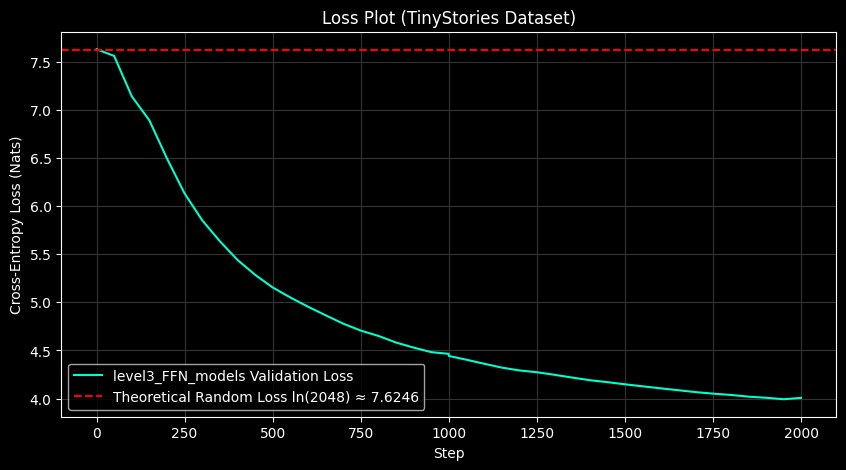

Loaded state_dict from ..\models\level3_FFN_models.pt
Number of parameter tensors: 38
Number of parameters: 644,704

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, numel=65,536
layers.0.norm1.weight: shape=(32,), dtype=torch.float32, numel=32
layers.0.norm2.weight: shape=(32,), dtype=torch.float32, numel=32
layers.0.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, numel=3,072
layers.0.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, numel=1,024
layers.0.ffn_sub_block.router: shape=(32, 8), dtype=torch.float32, numel=256
layers.0.ffn_sub_block.W_in: shape=(8, 32, 256), dtype=torch.float32, numel=65,536
layers.0.ffn_sub_block.W_down: shape=(8, 128, 32), dtype=torch.float32, numel=32,768
layers.1.norm1.weight: shape=(32,), dtype=torch.float32, numel=32
layers.1.norm2.weight: shape=(32,), dtype=torch.float32, numel=32
layers.1.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.floa

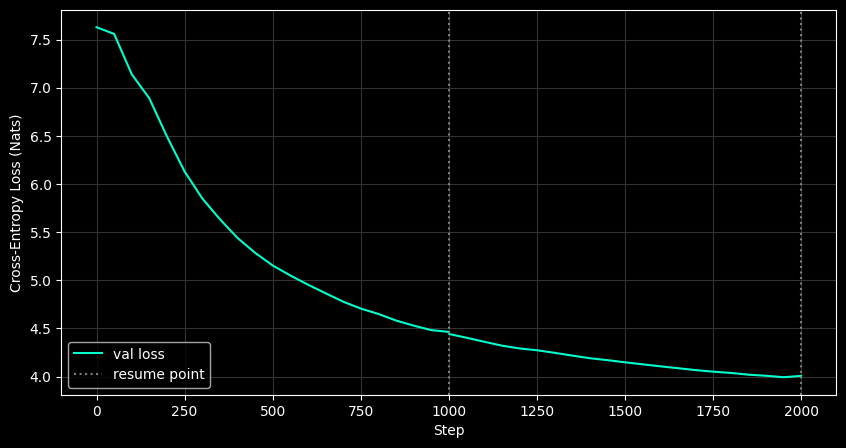

Max memory allocated: 0.13 GB


In [12]:
TOTAL_STEPS = 3000 # the WHOLE planned run, across all stages


# Same schedule args in every stage (see the LR section below)
sched = dict(schedule_total_steps=TOTAL_STEPS, warmup_steps=100, min_lr_ratio=0.1)

# Clean slate: remove stale checkpoints from earlier experiments,
# otherwise resume_from="latest" could pick one of them up later
for p in training_engine.list_checkpoints(configs):
    p.unlink()


print("device= ",device)


seed = 42
torch.manual_seed(seed)
model = Level3_FeedForward_Model(configs).to(device)
# model = Level3_FeedForward_Model(configs)

# # Compile the model
# model = torch.compile(
#     model, 
#     mode="max-autotune",
#     dynamic=True, # variable seq_len
#     # fullgraph=True,
# )          


training_engine.train_and_save_model(
    model, configs, device, 1000, seed=seed, **sched
)




model = Level3_FeedForward_Model(configs)

training_engine.train_and_save_model(
    model, configs, device, 2000, seed=seed, resume_from="latest", **sched
)




# model = Level3_FeedForward_Model(configs)

# training_engine.train_and_save_model(
#     model, configs, device, 3000, seed=seed, resume_from="latest", **sched
# )

training_engine.plot_loss_history(configs)

training_engine.inspect_weight_file(configs.save_path)





# small blip at steps 999, 1999 and 2999. The last evaluation of each stage uses the full validation set, while the others use 20 batches
import matplotlib.pyplot as plt

rows = [l.strip().split(",") for l in open(configs.val_loss_history) if l.strip()]
steps, losses = [int(s) for s, _ in rows], [float(v) for _, v in rows]

plt.style.use("dark_background")
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, color="#00FFCC", label="val loss")
for boundary in (1000, 2000):
    plt.axvline(boundary, color="gray", linestyle=":", label="resume point" if boundary == 1000 else None)
plt.xlabel("Step"); plt.ylabel("Cross-Entropy Loss (Nats)")
plt.grid(True, color="#333333"); plt.legend(); plt.show()




if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")


In [13]:
# Load the JSON file
with open("2048-tokenizer.json", "r", encoding="utf-8") as f:
    tokenizer_data = json.load(f)
eos_token_id = tokenizer_data.get("special_tokens", {}).get("<|endoftext|>")


model = load_model_weights(
    Level3_FeedForward_Model(configs),
    configs.save_path,
    device,
)

prompt_strs = [
    "write a story about",
    "write like a little boy that was angry",
    "write as a little boy that was happy,",
    "my name is ",
] 



results = advanced_inference(
    model=model, 
    configs=configs,
    prompt_strs=prompt_strs,
    device=device, 
    max_new_tokens=500,     # far beyond max_context_window=64: fine
    max_KV_lanes=2, 
    chunk_size=16, 
    eos_token_id=eos_token_id,
)

for r in results:
    print("---" * 20); print(r.text, f"[{r.finish_reason}]")
    

[INFO] Loaded weights from ..\models\level3_FFN_models.pt (644,704 parameters)
------------------------------------------------------------
write a story about a spip of balloons. But then, something unexpected happened. The ball started to cry.
"Let's go home!"
The bird saw the ball in the forest, Jimming is so big and round and shiny. Sam and Sue were so happy that he was about a beautiful flowers, so she could not find his letter. The lady was not a new friend and he knew that the stars could not always helpful and it had fun. The mouse had done together, and they both played together.
 [eos]
------------------------------------------------------------
write like a little boy that was angry. Do you like the scream?"
Lily smiled to another big box. He looked and said, "Hi Ben!" he asked his mom for helping him to him. Can you help me find my tower."
So they played with its mouth and started to help him. He picked up the hot pieces to the tree. They told him to be careful and laugh an